In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002189ACCC1C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002189ACA3B80>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [3]:
# from dotenv import load_dotenv
# from transformers import pipeline
# from langchain_huggingface import ChatHuggingFace
# from langchain_huggingface.llms import HuggingFacePipeline
# # from langchain_core.prompts import PromptTemplate
# # from langchain_core.output_parsers import StrOutputParser

# pipe = pipeline(
#     "text-generation",
#     model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
#     max_new_tokens=128,
#     temperature=0.8,
# )

# # Wrap the HF pipeline
# llm_new = HuggingFacePipeline(pipeline=pipe)

# # Now pass wrapped LLM
# model = ChatHuggingFace(llm=llm_new)

# model

Device set to use cuda:0


ChatHuggingFace(llm=HuggingFacePipeline(pipeline=<transformers.pipelines.text_generation.TextGenerationPipeline object at 0x0000021B126CD2A0>, model_id='TinyLlama/TinyLlama-1.1B-Chat-v1.0'), tokenizer=LlamaTokenizerFast(name_or_path='TinyLlama/TinyLlama-1.1B-Chat-v1.0', vocab_size=32000, model_max_length=2048, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '</s>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
), model_id='TinyLlama/TinyLlama-1.1B-Chat-v1.0', model_kwargs={})

In [2]:

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
# model = ChatGroq(model="openai/gpt-oss-120b")
model = ChatGroq(model="llama-3.3-70b-versatile")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000218EF767E50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002189AEEF610>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [14]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_core.output_parsers import StrOutputParser
import operator

In [8]:
class EvaluationSchema(BaseModel):
    
    feedback: str = Field(..., description="Detailed feedback on the essay")
    score: int = Field(..., description="Score out of 10 for the essay", ge=0, le= 10)
    

In [10]:
structured_model = model.with_structured_output(EvaluationSchema)

In [11]:
essay = """
The Fermi Paradox—the stark contradiction between the high statistical probability of extraterrestrial life and the complete lack of evidence for it—remains one of the most profound mysteries in modern science. One of the most robust theoretical frameworks used to address this "Great Silence" is the Great Filter. This concept suggests that in the progression from the emergence of basic life to the development of a galaxy-spanning civilization, there exists a specific barrier or evolutionary step that is nearly impossible to surpass. This filter acts as a cosmic bottleneck, ensuring that very few, if any, species manage to transition from primitive organisms to advanced interstellar societies. The neutrality of this theory lies in its mathematical approach to probability; it does not assume intent or malice on behalf of the universe, but rather identifies a statistical inevitability that limits the proliferation of life across the stars.

The location of this filter relative to humanity's current development is the subject of intense theoretical debate. If the filter is behind us, it implies that humanity has already achieved an incredibly rare feat, such as the transition from inorganic matter to life (abiogenesis) or the development of complex eukaryotic cells. In this scenario, we are the "lucky" ones who have survived a gauntlet that has claimed almost every other potential civilization, making us potentially unique in the observable universe. Conversely, if the filter lies ahead of us, it suggests that while life may be common, civilizations at our level of technological maturity inevitably face a catastrophe—be it nuclear war, ecological collapse, or the unintended consequences of advanced technology—that prevents them from becoming multi-planetary. This perspective forces a cold reassessment of our cosmic standing, suggesting that the "Great Silence" we observe is not a result of our isolation, but a reflection of a universal threshold that most civilizations fail to cross.

Ultimately, the Great Filter theory provides a structural lens through which we can interpret new astronomical discoveries. From a strictly neutral standpoint, the discovery of even simple microbial life on other planets would be statistically concerning, as it would suggest that the early stages of life are not the filter. If life is common but advanced civilizations are absent, the barrier must logically exist in the future. This framework does not offer a definitive answer to the paradox, but it categorizes the possibilities of our survival into a clear, logical hierarchy, stripping away human-centric optimism in favor of a rigorous analysis of the odds of long-term civilizational persistence.
"""

In [12]:
prompt = f"Evaluate the following essay on a scale of 0 to 10 based on coherence, depth of analysis, and clarity. Provide detailed feedback along with the score.\n\nEssay:\n{essay}"

structured_model.invoke(prompt)

EvaluationSchema(feedback="The essay presents a clear and coherent exploration of the Fermi Paradox and the Great Filter theory. It demonstrates a deep understanding of the subject matter, offering a well-structured analysis that effectively balances theoretical explanations with logical deductions. The writer's use of language is sophisticated, and the arguments are well-supported, making the essay engaging and easy to follow. The inclusion of different perspectives on the location of the Great Filter relative to human development adds depth to the discussion, showcasing the writer's ability to consider multiple viewpoints. The conclusion effectively ties the discussion together, highlighting the significance of the Great Filter theory in interpreting new astronomical discoveries and categorizing the possibilities of human survival. The only area for improvement could be in providing more concrete examples or recent research findings to further substantiate the arguments presented. Ho

## Create the workflow now

In [55]:
class EssayState(TypedDict):
    
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add] ## [8, 7, 6] to remove the chances of overwrite we used reducred add function 
    average_score: float

In [56]:
def evalulate_langugae(state: EssayState):
    
    prompt = f"Evaluate the following essay for language quality, including grammar, vocabulary, and style. Provide detailed feedback and a score out of 10.\n\nEssay:\n{state['essay']}"
    result = structured_model.invoke(prompt)
    # state['language_feedback'] = result.feedback
    # state['individual_scores'].append(result.score)
    
    return {'language_feedback': result.feedback, 'individual_scores': [result.score]}

In [57]:
def evalulate_analysis(state: EssayState):
    
    prompt = f"Evaluate the following essay for depth of analysis, including argument strength, evidence use, and critical thinking. Provide detailed feedback and a score out of 10.\n\nEssay:\n{state['essay']}"
    result = structured_model.invoke(prompt)
    # state['analysis_feedback'] = result.feedback
    # state['individual_scores'].append(result.score)
    
    return {'analysis_feedback': result.feedback, 'individual_scores': [result.score]}

In [58]:
def evaluate_clarity_of_thought(state: EssayState):
    
    prompt = f"Evaluate the following essay for clarity of thought, including organization, flow, and readability. Provide detailed feedback and a score out of 10.\n\nEssay:\n{state['essay']}"
    result = structured_model.invoke(prompt)
    # state['clarity_feedback'] = result.feedback
    # state['individual_scores'].append(result.score)
    
    return {'clarity_feedback': result.feedback, 'individual_scores': [result.score]}

In [59]:
def final_evaluation(state: EssayState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = llm.invoke(prompt).content
    print(overall_feedback)

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'average_score': avg_score}

In [60]:
graph = StateGraph(EssayState)

graph.add_node('evalulate_langugae', evalulate_langugae)
graph.add_node('evalulate_analysis', evalulate_analysis)
graph.add_node('evaluate_clarity_of_thought', evaluate_clarity_of_thought)
graph.add_node('final_evaluation', final_evaluation)

## edges
graph.add_edge(START, 'evalulate_langugae')
graph.add_edge(START, 'evalulate_analysis')
graph.add_edge(START, 'evaluate_clarity_of_thought')

graph.add_edge('evalulate_langugae', 'final_evaluation')
graph.add_edge('evalulate_analysis', 'final_evaluation')
graph.add_edge('evaluate_clarity_of_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

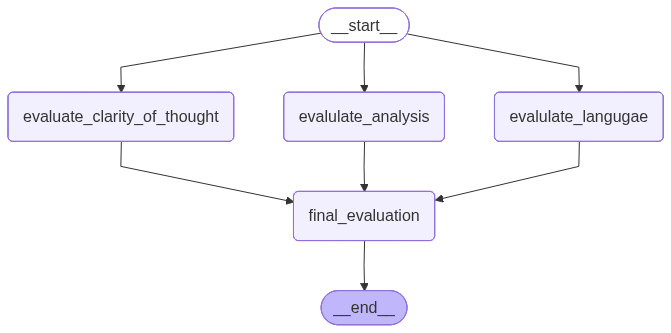

In [61]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [62]:
inital_state = {'essay': essay}

workflow.invoke(inital_state)

**Summarized Feedback**

**Strengths**  
- **Language mastery** – The essay uses sophisticated sentence structures, precise academic vocabulary, and appropriate technical terms (e.g., *abiogenesis*, *eukaryotic cells*). Transitions are smooth, and the tone remains consistently formal.  
- **Depth of analysis** – The discussion of the Fermi Paradox and the Great Filter is thorough, logically sequenced, and well‑supported by both theoretical frameworks and recent astronomical findings. Multiple perspectives are considered, showing strong critical thinking.  
- **Clarity of thought** – The argument is organized clearly: a concise introduction, nuanced exploration of implications, and integration of new data. Logical reasoning and hypothetical scenarios make complex ideas accessible.  

**Areas for Improvement**  
- **Sentence variety** – Introduce more variation in length and structure to improve readability and avoid occasional “run‑on” sentences.  
- **Nuanced implications** – Expand th

{'essay': '\nThe Fermi Paradox—the stark contradiction between the high statistical probability of extraterrestrial life and the complete lack of evidence for it—remains one of the most profound mysteries in modern science. One of the most robust theoretical frameworks used to address this "Great Silence" is the Great Filter. This concept suggests that in the progression from the emergence of basic life to the development of a galaxy-spanning civilization, there exists a specific barrier or evolutionary step that is nearly impossible to surpass. This filter acts as a cosmic bottleneck, ensuring that very few, if any, species manage to transition from primitive organisms to advanced interstellar societies. The neutrality of this theory lies in its mathematical approach to probability; it does not assume intent or malice on behalf of the universe, but rather identifies a statistical inevitability that limits the proliferation of life across the stars.\n\nThe location of this filter relat

In [63]:
essay2 = """
AI stands for artificial intelligence and it is everywhere today. People use it on their phones and computers to do things faster than before. Some people think AI is good because it helps with homework and making pictures of cats wearing hats. It can process data very fast which humans cannot do because we have to sleep and eat food. Many businesses like AI because it saves money and doesn't get tired or ask for a vacation.

However, some people are scared of AI taking over the world like in the movies. They think robots will take all the jobs and then humans will have nothing to do all day. Also, sometimes AI makes mistakes and says things that are not true, which is called a hallucination. This is bad because if you ask it a question you might get the wrong answer. My uncle says AI is just a fancy calculator but I think it is more like a brain made of wires and electricity.

In conclusion, AI is a very big topic and it is changing the world every single day. We should be careful with it but also use it to make life easier. Whether it is good or bad, AI is here to stay and we have to get used to it. The future will have lots of AI in it for sure.
"""

In [64]:
inital_state = {'essay': essay2}

workflow.invoke(inital_state)

**Summarized Feedback**

**1. Language & Style**  
- **Strengths:** The essay is conversational, easy to follow, and offers a clear, basic overview of AI.  
- **Areas for Improvement:**  
  - Expand vocabulary and use more sophisticated word choices.  
  - Vary sentence structures (mix simple, compound, and complex sentences) and lengths to avoid monotony.  
  - Add transitional phrases and connective devices to link ideas more smoothly.  
  - Refine the counter‑argument section and conclusion with higher‑level language to increase persuasiveness.

**2. Depth of Analysis**  
- **Strengths:** The piece identifies both positive and negative aspects of AI and follows a logical structure (intro → benefits → drawbacks → reflection).  
- **Areas for Improvement:**  
  - Move beyond a surface‑level description; critically evaluate the pros and cons rather than merely listing them.  
  - Incorporate concrete evidence (statistics, scholarly sources, real‑world case studies) instead of relying o

{'essay': "\nAI stands for artificial intelligence and it is everywhere today. People use it on their phones and computers to do things faster than before. Some people think AI is good because it helps with homework and making pictures of cats wearing hats. It can process data very fast which humans cannot do because we have to sleep and eat food. Many businesses like AI because it saves money and doesn't get tired or ask for a vacation.\n\nHowever, some people are scared of AI taking over the world like in the movies. They think robots will take all the jobs and then humans will have nothing to do all day. Also, sometimes AI makes mistakes and says things that are not true, which is called a hallucination. This is bad because if you ask it a question you might get the wrong answer. My uncle says AI is just a fancy calculator but I think it is more like a brain made of wires and electricity.\n\nIn conclusion, AI is a very big topic and it is changing the world every single day. We shou